In [8]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [8]:
# # Add metadata
# map = r'O:\HybridDune experiment\data Kellers\NetCDF' # 16to18dec
# file_names = [r'Keller pressure transducers, 16-18dec2024 (before storm1), 10Hz.nc',
#               r'Keller pressure transducers, 2-3jan2025 (between storm3 and 4), 10Hz.nc',
#               r'Keller pressure transducers, 23-31dec2024 (between storm2 and 3), 10Hz.nc',
#               r'Keller pressure transducers, 8-10jan2025 (after storm 5), S4Wall-in-dune, 10Hz.nc',
#               r'Keller pressure transducers, storm 1 and 2, 1000Hz - p removed.nc',
#               r'Keller pressure transducers, storm 3, 1000Hz.nc',
#               r'Keller pressure transducers, storm4 and 5 (3jan2025 18,14 to 8jan2025), S4 Wall-in-dune, 1000Hz.nc',
#               r'Keller pressure transducers, storm4, file1 (3jan2025 17,15-17,31), 1000Hz.nc',
#               r'Keller pressure transducers, storm4, file2 (3jan2025 17,40-18,10), S4 Wall-in-dune, 1000Hz.nc',
#               r'Keller pressure transducers, test 12, 1 Hz.nc']
# sf_list = [10, 10, 10, 10, 1000, 1000, 1000, 1000, 1000, 1]  # sampling frequencies corresponding to the files

# for file_name, sf in zip(file_names, sf_list):
#     nc_out = f'{map}\\{file_name}'
#     ds = xr.Dataset(coords={"temp": 1}) # make dataset (coordinate not used, easy wat to make a dataset)

#     # Add sampling frequency metadata
#     ds['sf'] = sf                                            # sampling frequency [hz]
#     ds.sf.attrs = {'units': 'Hz', 'long_name': 'sampling frequency'}
#     ds[["sf"]].to_netcdf(nc_in, mode="a", engine="netcdf4")
#     print(f'{file_name} finished')




In [4]:
map = r'O:\HybridDune experiment\data Kellers\NetCDF' # 16to18dec
file_names = [r'Keller pressure transducers, 16-18dec2024 (before storm1), 10Hz.nc',
              r'Keller pressure transducers, storm 1 and 2, 1000Hz - p removed.nc',
              r'Keller pressure transducers, 23-31dec2024 (between storm2 and 3), 10Hz.nc',
              r'Keller pressure transducers, storm 3, 1000Hz.nc',
              r'Keller pressure transducers, 2-3jan2025 (between storm3 and 4), 10Hz.nc',
              r'Keller pressure transducers, storm4, file1 (3jan2025 17,15-17,31), 1000Hz.nc',
              r'Keller pressure transducers, storm4, file2 (3jan2025 17,40-18,10), S4 Wall-in-dune, 1000Hz.nc',
              r'Keller pressure transducers, storm4 and 5 (3jan2025 18,14 to 8jan2025), S4 Wall-in-dune, 1000Hz.nc',
              r'Keller pressure transducers, 8-10jan2025 (after storm 5), S4Wall-in-dune, 10Hz.nc']
titles_files = ['Before storm 1',
                'Storm 1 and 2',
                'Between storm 2 and 3',
                'Storm 3',
                'Between storm 3 and 4',
                'Storm 4, file 1',
                'Storm 4, file 2',
                'Storm 4 and 5',
                'After storm 5']

In [10]:
ds

<xarray.DataArray 'x_RD' (section: 5, sensor: 12)> Size: 480B
[60 values with dtype=float64]
Coordinates:
  * section  (section) <U15 300B 'S1 Dike-in-dune' '' ... 'ref.Pt1'
Dimensions without coordinates: sensor
Attributes:
    long name:  x position of instrument in RDNAP coordinates
    units:      m
    epsg:       28992.0

Processing file 7 of 9: Storm 4, file 2
data processed


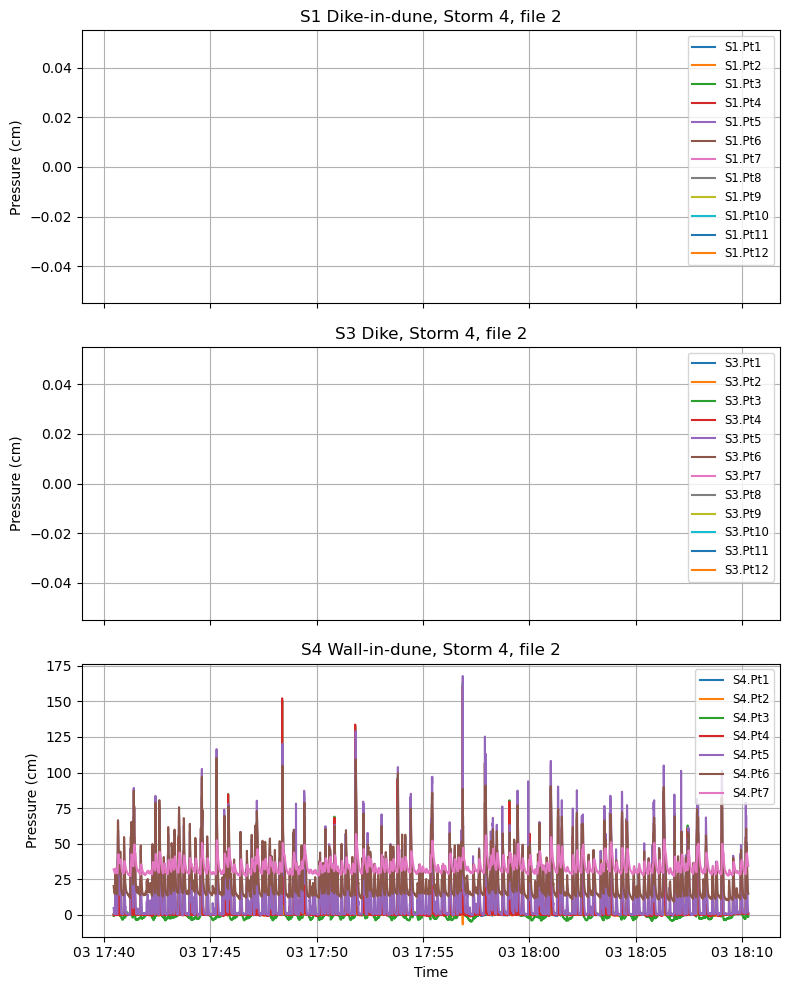

Processing file 8 of 9: Storm 4 and 5
data processed


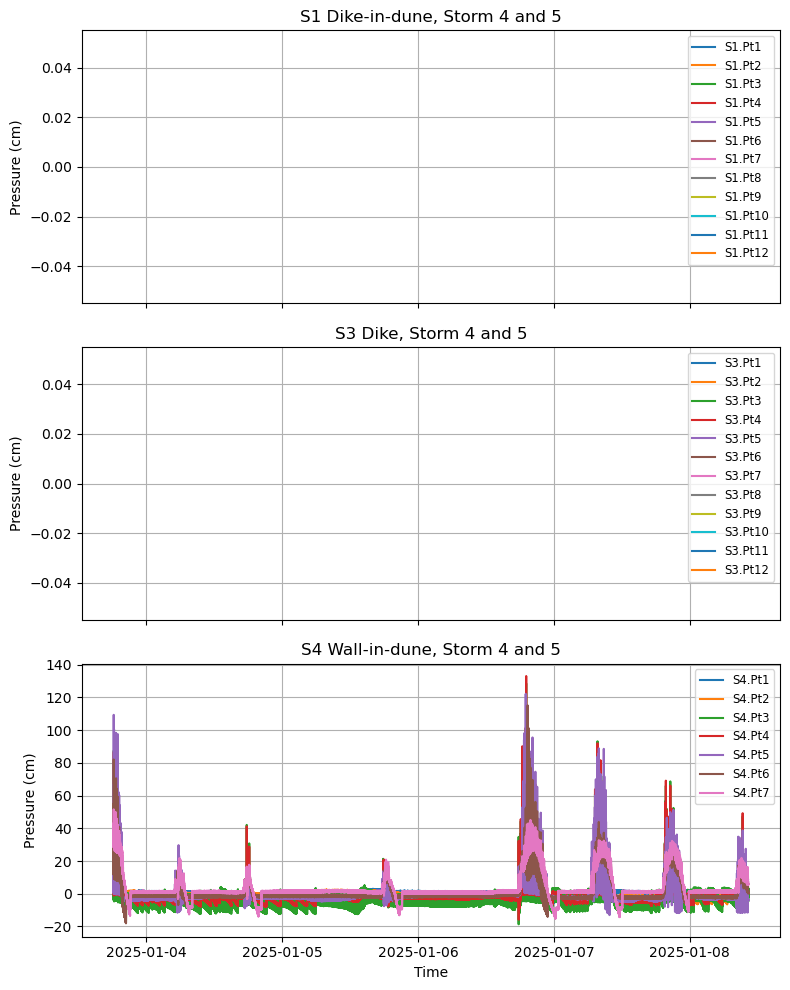

Processing file 9 of 9: After storm 5
data processed


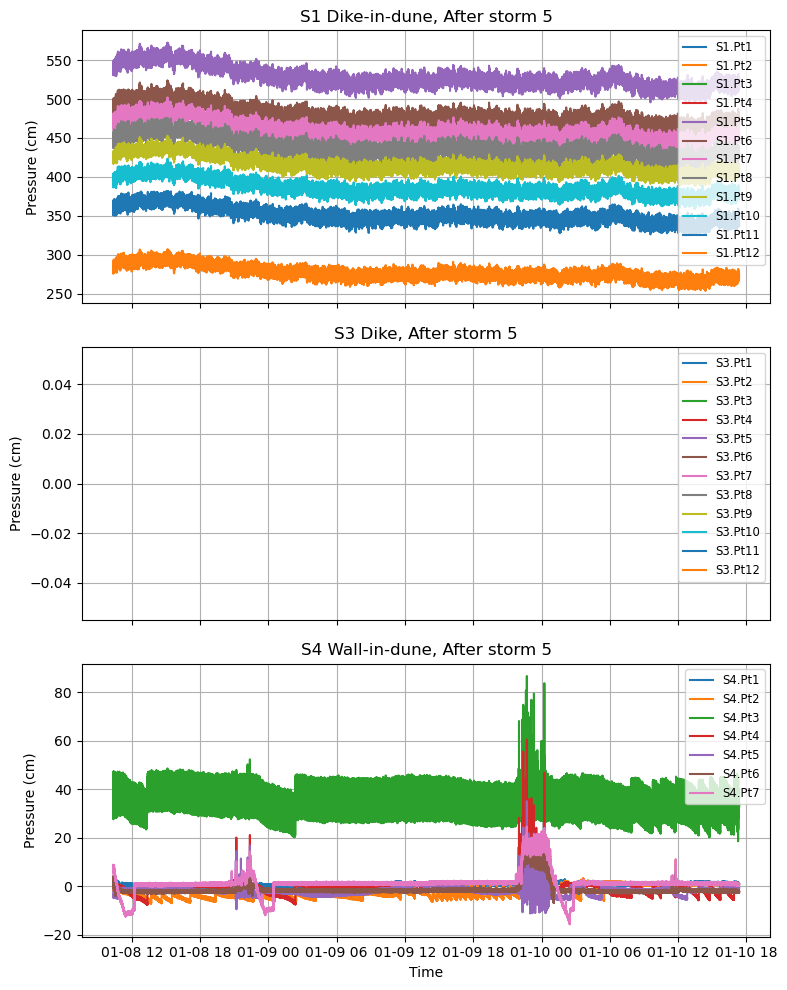

In [7]:
# Pre-define plotting info
sections = [0, 2, 3]   # subplot 0, 1 and 2 plot S0, S1 and S3 (0-based indexing)
n_sensors = {0: 12, 2: 12, 3: 7}  # number of sensors per section
titles = ['S1 Dike-in-dune', 'S3 Dike', 'S4 Wall-in-dune']

# Load and plot dataset
for n_file in range(6,9): #range(len(file_names)):
    # Load data -------------------------------------------------------------------
    print(f'Processing file {n_file+1} of {len(file_names)}: {titles_files[n_file]}')
    ds = xr.open_dataset(f'{map}/{file_names[n_file]}')
    sf = ds.sf.values # Hz
    if sf == 1000:
        ds = xr.open_dataset(f'{map}/{file_names[n_file]}', chunks="auto").isel(t=slice(0, None, 100))  # downsample to 10 Hz for plotting
    U = ds['voltage']
    z_i = ds['z_instrument']
    t = ds['t']

    p = 1e5 * (0.15*U+0.5)
    p_ref = p[4, 0, :].rolling(t=10*10).mean() # window 10s * 10 hz
    p = p - p_ref # subtract air pressure
    p = p / 10000 * 100 # Convert Pa to cm
    print('data processed')

    # Make plot -------------------------------------------------------------------
    fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

    for ax, s, title in zip(axes, sections, titles):
        # Plot all sensors as separate lines
        for n in range(n_sensors[s]):  # iterate over sensors for this section
            ax.plot(t[::5], p[s, n, ::5], label=f'S{s+1}.Pt{n+1}')        # plot every 5th point to reduce number of points (2Hz)
        ax.set_ylabel('Pressure (cm)')
        ax.set_title(f'{title}, {titles_files[n_file]}')
        ax.grid(True)
        ax.legend(loc='upper right', fontsize='small')

    axes[-1].set_xlabel('Time')
    plt.tight_layout()
    plt.show()

    fig_out = r'O:\HybridDune experiment\data Kellers\figures' + f'/Keller plot {n_file+1} - {titles_files[n_file]}.png'
    fig.savefig(fig_out, dpi=300)

In [14]:
sections = [0, 2, 3]   # subplot 0, 1 and 2 plot S0, S1 and S3 (0-based indexing)
n_sensors = {0: 12, 2: 12, 3: 7}  # number of sensors per section
titles = ['S1 Dike-in-dune', 'S3 Dike', 'S4 Wall-in-dune']

# Plot, check if sensors filled with sand were affected
n_file = 5 # last file with all sections. And 15min file, so quicker loading

# Load data -------------------------------------------------------------------
print(f'Processing file {n_file+1} of {len(file_names)}: {titles_files[n_file]}')
ds = xr.open_dataset(f'{map}/{file_names[n_file]}')
sf = ds.sf.values # Hz
if sf == 1000:
    ds = xr.open_dataset(f'{map}/{file_names[n_file]}', chunks="auto").isel(t=slice(0, None, 100))  # downsample to 10 Hz for plotting
U = ds['voltage']
z_i = ds['z_instrument']
t = ds['t']

p = 1e5 * (0.15*U+0.5)
p_ref = p[4, 0, :].rolling(t=10*10).mean() # window 10s * 10 hz
p = p - p_ref # subtract air pressure
p = p / 10000 * 100 # Convert Pa to cm

t = t[::5]
p = p[:,:,::5]
print('data processed')



Processing file 6 of 9: Storm 4, file 1
data processed


In [16]:
p

<xarray.DataArray 'voltage' (section: 5, sensor: 12, t: 1911)> Size: 917kB
dask.array<getitem, shape=(5, 12, 1911), dtype=float64, chunksize=(4, 4, 1911), chunktype=numpy.ndarray>
Coordinates:
  * section  (section) <U15 300B 'S1 Dike-in-dune' '' ... 'ref.Pt1'
  * t        (t) datetime64[ns] 15kB 2025-01-03T17:15:13 ... 2025-01-03T17:31:08
    temp     int64 8B 1
Dimensions without coordinates: sensor

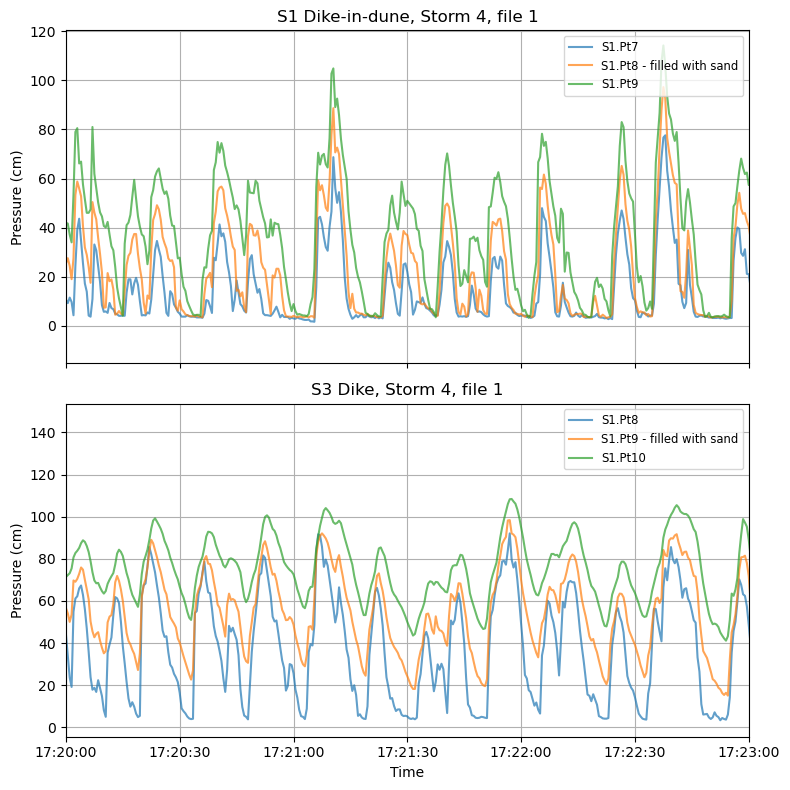

In [26]:
# Make plot -------------------------------------------------------------------
sections = [0, 2 ]   # subplot 0, 1 and 2 plot S0, S1 and S3 (0-based indexing)
n_sensors_start = {0: 6, 2: 7}  # number of sensors per section
n_sensors_end   = {0: 9, 2: 10}  # number of sensors per section
titles = ['S1 Dike-in-dune', 'S3 Dike']

fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
axes[0].plot(t, p[0,6,:], alpha = 0.7, label='S1.Pt7')
axes[0].plot(t, p[0,7,:], alpha = 0.7, label='S1.Pt8 - filled with sand')
axes[0].plot(t, p[0,8,:], alpha = 0.7, label='S1.Pt9')
axes[0].set_title(f'{titles[0]}, {titles_files[n_file]}')
axes[0].set_ylabel('Pressure (cm)')
axes[0].set_xlim(pd.to_datetime('2025-01-03 17:20'), pd.to_datetime('2025-01-03 17:23'))
axes[0].legend(loc='upper right', fontsize='small')
axes[0].grid(True)

axes[1].plot(t, p[2,7,:], alpha = 0.7, label='S1.Pt8')
axes[1].plot(t, p[2,8,:], alpha = 0.7, label='S1.Pt9 - filled with sand')
axes[1].plot(t, p[2,9,:], alpha = 0.7, label='S1.Pt10')
axes[1].set_title(f'{titles[1]}, {titles_files[n_file]}')
axes[1].set_ylabel('Pressure (cm)')
axes[1].set_xlim(pd.to_datetime('2025-01-03 17:20'), pd.to_datetime('2025-01-03 17:23'))
axes[1].legend(loc='upper right', fontsize='small')
axes[1].grid(True)
axes[1].set_xlabel('Time')

plt.tight_layout()
plt.show()

#fig_out = r'O:\HybridDune experiment\data Kellers\figures' + f'/Keller plot {n_file+1} - {titles_files[n_file]}.png'
#fig.savefig(fig_out, dpi=300)